In [122]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Data Loading

In [219]:
df = duckdb.sql("""
    SELECT
        trips.* EXCLUDE (store_and_fwd_flag),
        pu_zones.Borough AS pickup_borough,
        do_zones.Borough AS dropoff_borough
    FROM '../data/yellow_tripdata_2026-01.parquet' AS trips
    LEFT JOIN '../data/taxi_zone_lookup.csv' AS pu_zones
        ON trips.PULocationID = pu_zones.LocationID
    LEFT JOIN '../data/taxi_zone_lookup.csv' AS do_zones
        ON trips.DOLocationID = do_zones.LocationID
    WHERE
        trips.passenger_count > 0
        AND trips.trip_distance > 0 
        AND trips.fare_amount > 0 
""").df()

df.head()



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_borough,dropoff_borough
0,2,2026-01-24 18:45:53,2026-01-24 19:23:49,1,7.86,1,249,256,1,42.2,...,0.5,9.39,0.0,1.0,56.34,2.5,0.0,0.75,Manhattan,Brooklyn
1,2,2026-01-24 18:11:37,2026-01-24 18:14:20,1,0.25,1,113,113,1,4.4,...,0.5,3.66,0.0,1.0,12.81,2.5,0.0,0.75,Manhattan,Manhattan
2,2,2026-01-24 18:24:42,2026-01-24 18:51:39,2,5.97,1,113,166,1,31.7,...,0.5,5.47,0.0,1.0,41.92,2.5,0.0,0.75,Manhattan,Manhattan
3,2,2026-01-24 18:59:21,2026-01-24 19:06:12,1,0.63,1,238,238,1,7.9,...,0.5,1.19,0.0,1.0,13.09,2.5,0.0,0.00,Manhattan,Manhattan
4,2,2026-01-24 18:51:38,2026-01-24 19:05:37,1,2.23,1,141,224,2,14.2,...,0.5,0.00,0.0,1.0,18.95,2.5,0.0,0.75,Manhattan,Manhattan


# Null Checks

In [220]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
cbd_congestion_fee       0
pickup_borough           0
dropoff_borough          0
dtype: int64

In [241]:
df.duplicated().sum()

np.int64(0)

# Summary Statistics

In [221]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,2.551851e+06,2551851,2551851,2.551851e+06,2.551851e+06,2.551851e+06,2.551851e+06,2.551851e+06,2.551851e+06,2.551851e+06,2.551851e+06,2.551851e+06,2.551851e+06,2.551851e+06,2.551851e+06,2.551851e+06,2.551851e+06,2.551851e+06,2.551851e+06
mean,1.870404e+00,2026-01-16 16:10:06.577445,2026-01-16 16:27:10.533282,1.260719e+00,3.483186e+00,5.313607e+00,1.654756e+02,1.651989e+02,1.155679e+00,1.943825e+01,1.472477e+00,4.937205e-01,3.577366e+00,5.784512e-01,9.568043e-01,2.891720e+01,2.225639e+00,1.570743e-01,5.247159e-01
min,1.000000e+00,2025-12-31 23:57:29,2025-12-31 23:57:32,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,2026-01-09 11:54:00.500000,2026-01-09 12:10:44.500000,1.000000e+00,9.800000e-01,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.638000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2026-01-16 09:48:56,2026-01-16 10:05:49,1.000000e+00,1.660000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.280000e+01,1.000000e+00,5.000000e-01,2.940000e+00,0.000000e+00,1.000000e+00,2.142000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2026-01-23 15:19:46.500000,2026-01-23 15:40:09,1.000000e+00,3.300000e+00,1.000000e+00,2.340000e+02,2.360000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.410000e+00,0.000000e+00,1.000000e+00,3.083000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2026-02-01 00:45:01,2026-02-01 23:35:31,8.000000e+00,9.877358e+04,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,2.555200e+03,1.746000e+01,4.750000e+00,7.660000e+02,1.222200e+02,1.000000e+00,2.560200e+03,2.500000e+00,2.675000e+01,7.500000e-01
std,7.928821e-01,NaN,NaN,6.617710e-01,6.630610e+01,1.991456e+01,6.351417e+01,6.956570e+01,4.514822e-01,1.838895e+01,1.845902e+00,5.585360e-02,4.087710e+00,2.261430e+00,2.032974e-01,2.271500e+01,7.814270e-01,5.254758e-01,3.438171e-01


# Date/Time Distributions

In [222]:
import datetime as dt

In [223]:
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['trip_duration'].describe()

count    2.551851e+06
mean     1.706593e+01
std      2.779335e+01
min     -1.170000e+01
25%      7.283333e+00
50%      1.220000e+01
75%      2.040000e+01
max      5.293333e+03
Name: trip_duration, dtype: float64

In [224]:

neg_durations = (df['trip_duration'] < 0).sum()
hour_2 = (df['trip_duration'] > 120).sum()
hour_3 = (df['trip_duration'] > 180).sum()
print(f'Negative durations: {neg_durations} ({round(neg_durations/len(df), 5)})% ')
print(f'Journeys over 2 hours: {hour_2} ({round(hour_2/len(df), 3)}%)')
print(f'Journeys over 3 hours: {hour_3} ({round(hour_3/len(df), 3)}%)')

Negative durations: 1 (0.0)% 
Journeys over 2 hours: 4200 (0.002%)
Journeys over 3 hours: 1525 (0.001%)


In [225]:
print('Upper quartiles for trip durations.')
print(df['trip_duration'].quantile([0.95, 0.99, 0.999]))

Q1 = df['trip_duration'].quantile(0.25)
Q3 = df['trip_duration'].quantile(0.75)
IQR = Q3 - Q1
exclusion_band = Q3 + 3*IQR
print('Upper bound: ', exclusion_band)

Upper quartiles for trip durations.
0.950     46.700000
0.990     77.750000
0.999    136.469167
Name: trip_duration, dtype: float64
Upper bound:  59.74999999999999


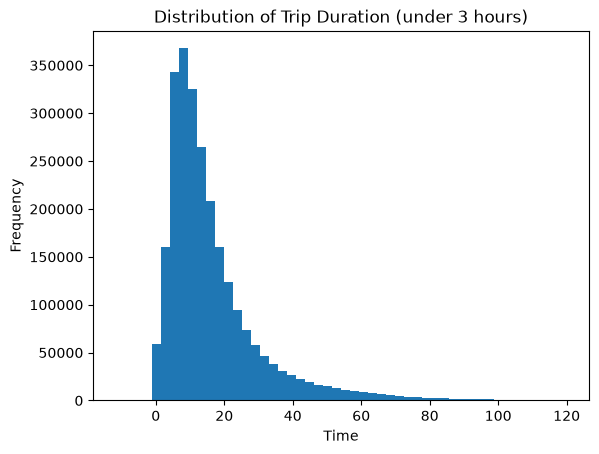

In [226]:
plt.hist(df[df['trip_duration'] < 120]['trip_duration'], bins = 50)
plt.title('Distribution of Trip Duration (under 3 hours)')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

In [227]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek  # 0=Monday
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

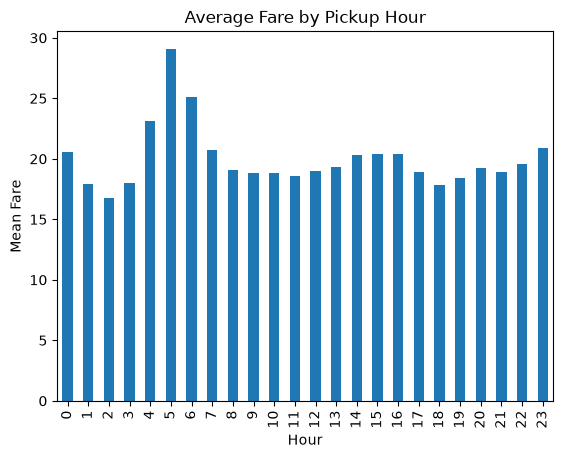

In [228]:
df.groupby('pickup_hour')['fare_amount'].mean().plot(kind='bar')
plt.title('Average Fare by Pickup Hour')
plt.xlabel('Hour')
plt.ylabel('Mean Fare')
plt.show()

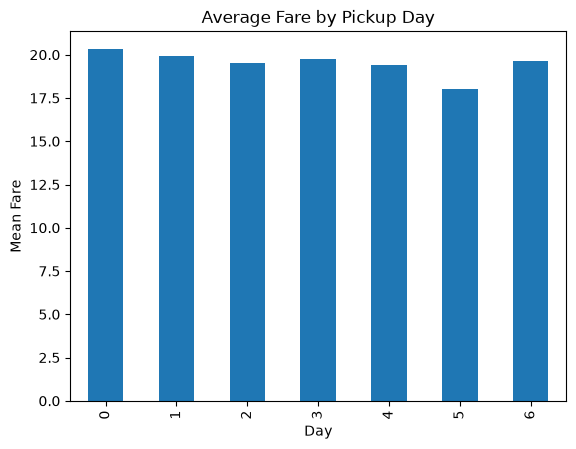

In [229]:
df.groupby('pickup_dayofweek')['fare_amount'].mean().plot(kind='bar')
plt.title('Average Fare by Pickup Day')
plt.xlabel('Day')
plt.ylabel('Mean Fare')
plt.show()

# Pickup/Dropoff Locations

In [230]:
df['pickup_borough'].value_counts()

pickup_borough
Manhattan        2222407
Queens            259305
Brooklyn           47074
Bronx              18342
Unknown             3843
N/A                  672
EWR                  117
Staten Island         91
Name: count, dtype: int64

In [231]:
df['dropoff_borough'].value_counts()

dropoff_borough
Manhattan        2254132
Brooklyn          125171
Queens            124038
Bronx              25896
N/A                11898
EWR                 5146
Unknown             4930
Staten Island        640
Name: count, dtype: int64

# RateCodeID 

In [232]:
df['RatecodeID'].value_counts()

RatecodeID
1     2325108
99     110268
2       79030
5       19825
3        9775
4        7843
6           2
Name: count, dtype: int64

In [233]:
df[df['RatecodeID'] == 99][['trip_distance', 'fare_amount', 'trip_duration']].describe()

,trip_distance,fare_amount,trip_duration
count,110268.000000,110268.000000,110268.000000
mean,9.028991,35.439073,55.798173
std,5.751584,12.373473,57.863576
min,0.010000,8.500000,-11.700000
25%,4.500000,25.500000,31.600000
50%,8.300000,33.500000,47.250000
75%,12.500000,43.500000,68.066667
max,223.600000,108.500000,1777.266667


# Trip Distance Distribution

In [234]:
print('Upper quartiles for trip distance.')
print(df['trip_distance'].quantile([0.95, 0.99, 0.999]))

Q1 = df['trip_distance'].quantile(0.25)
Q3 = df['trip_distance'].quantile(0.75)
IQR = Q3 - Q1
exclusion_band = Q3 + 3*IQR
print('Upper bound: ', exclusion_band)



Upper quartiles for trip distance.
0.950    15.2000
0.990    20.2000
0.999    30.7915
Name: trip_distance, dtype: float64
Upper bound:  10.259999999999998


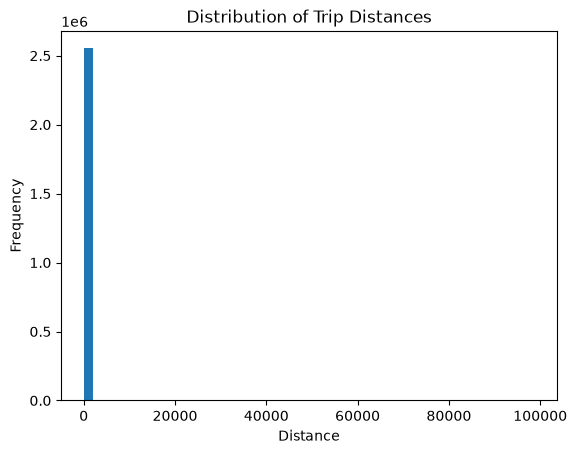

In [235]:
plt.hist(df['trip_distance'], bins = 50)
plt.title("Distribution of Trip Distances")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

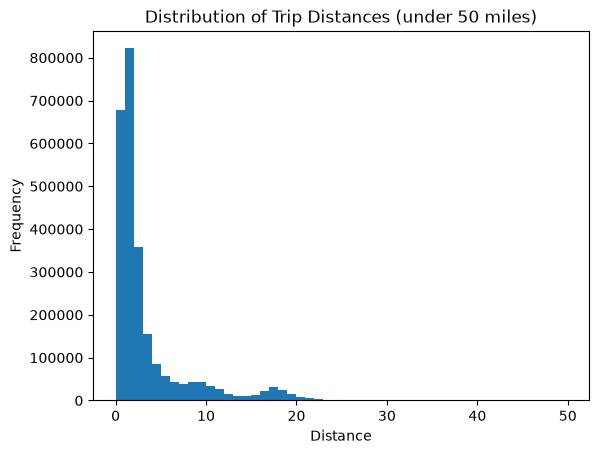

In [236]:
plt.hist(df[df['trip_distance'] < 50]['trip_distance'], bins = 50)
plt.title("Distribution of Trip Distances (under 50 miles)")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

# Fare Amount Distribution

In [237]:
print('Upper quartiles for fare amounts.')
print(df['fare_amount'].quantile([0.95, 0.99, 0.999]))

Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1
exclusion_band = Q3 + 3*IQR
print('Upper bound: ', exclusion_band)

Upper quartiles for fare amounts.
0.950     65.0
0.990     81.4
0.999    150.0
Name: fare_amount, dtype: float64
Upper bound:  61.8


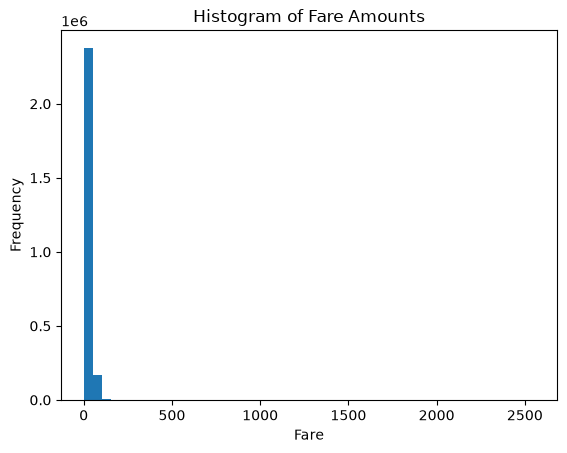

In [238]:
plt.hist(df['fare_amount'], bins = 50)
plt.title('Histogram of Fare Amounts')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

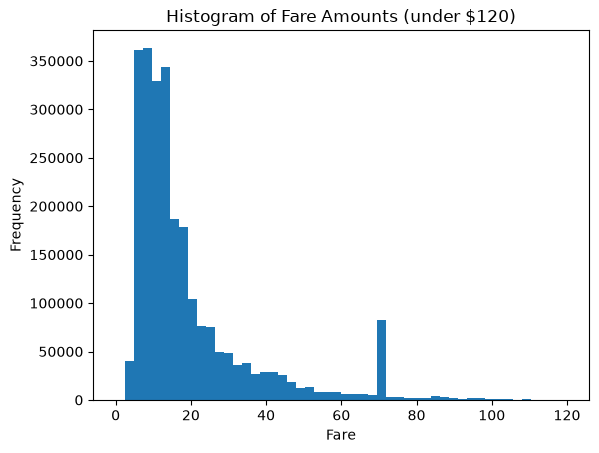

In [239]:
plt.hist(df[df['fare_amount'] < 120]['fare_amount'], bins = 50)
plt.title('Histogram of Fare Amounts (under $120)')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

# Fare Against Distance

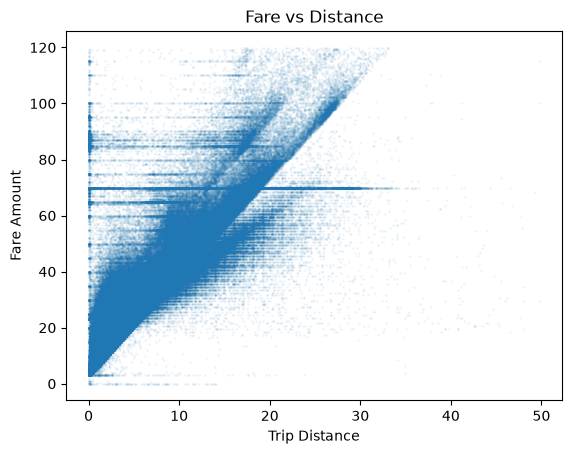

In [244]:
mask = (df['trip_distance'] < 50) & (df['fare_amount'] < 120)

plt.scatter(df[mask]['trip_distance'], df[mask]['fare_amount'], alpha=0.05, s=1)
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.title('Fare vs Distance')
plt.show()

# Correlation

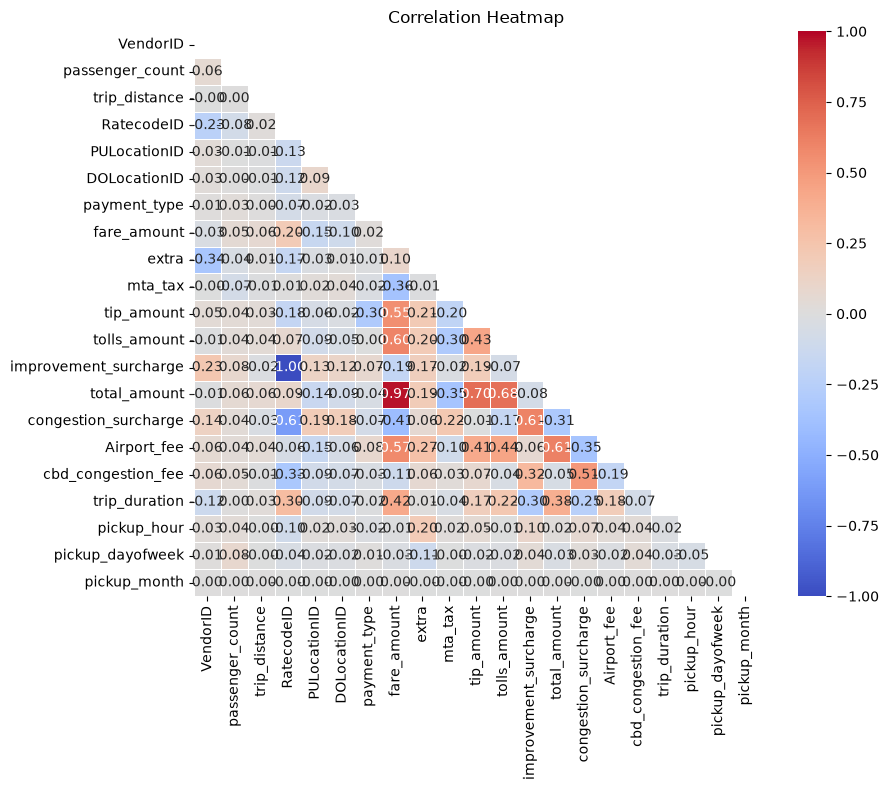

In [245]:
corr = df.corr(numeric_only=True)

# 2. Mask the upper triangle (optional but recommended)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,       # show correlation values
    fmt=".2f",        # format numbers
    cmap="coolwarm",  # diverging palette for correlations
    vmin=-1, vmax=1,  # correlation range
    center=0,         # zero = neutral colour
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Modelling Decisions

We want:
- `passenger_count` greater than 0
- `RatecodeID` with new columns `other` which include is code 99 
- consider a flat rate for JFJ airport at $70
- `PULocationID` and `DOLocationID` converted to their boroughs for easy when modelling 
- `trip_duration` between 0 and 2 hours and exclude negative durations
- new columns including `pickup_hour` and `pickup_dayofweek`
- `trip_distance` between 0 and 50 miles
- `fare_amount`  between 0 and $120